# 02 · Análisis exploratorio y diagnóstico de calidad

Ecobici (Buenos Aires) — fuentes:

| Fuente | Contenido | Granularidad |
|---|---|---|
| `archive/stations/buenos-aires/ecobici/AAAA/Mes.parquet` | Fotos (snapshots) del feed GBFS: bicis disponibles, rotas, docks, capacidad | estación × foto (~cada 12–16 min) |
| `archive/weather/buenos-aires/AAAA/Mes.parquet` | Pronóstico horario de Open-Meteo (temperatura, lluvia, viento) | hora pronosticada × momento de descarga |
| `recorridos-realizados-AAAA.zip` (BA Data, en `TRIPS_DIR`) | Viajes realizados: ID, duración, origen/destino, usuario, modelo, género | viaje (2024 → ago-2026) |

**Target = proxy de retiros.** Cada caída de `num_bikes_available` entre dos fotos consecutivas de la misma estación
cuenta como retiros. Los viajes de BA Data se usan para describir la demanda real, diagnosticar su calidad y
validar el proxy (sección 8).

In [1]:
from pathlib import Path
import glob
import os
import warnings
import zipfile

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import folium
from folium.plugins import HeatMap
import holidays

warnings.filterwarnings("ignore", message="Converting to PeriodArray")
pd.set_option("display.width", 200, "display.max_columns", 30)

REPO_DIR = Path("..").resolve()
DATA_DIR = Path(os.environ.get("ECOBICI_DATA_DIR", REPO_DIR / "datasets")).resolve()  # igual que en el notebook 01
ARCHIVE = DATA_DIR / "archive"  # fotos y pronósticos (buenos-aires.zip, descomprimido por el notebook 01)
TRIPS_DIR = DATA_DIR / "ba-ecobici-datasets"  # carpeta con recorridos-realizados-AAAA.zip
TZ = "America/Argentina/Buenos_Aires"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold"})

assert (ARCHIVE / "stations").exists(), f"No se encontró {ARCHIVE}. Correr antes el notebook 01, que descomprime los datos."
assert sorted(TRIPS_DIR.glob("recorridos-realizados-*.zip")), f"No se encontraron los ZIP de recorridos en {TRIPS_DIR}."

In [2]:
COLS = ["station_id", "name", "short_name", "external_id", "longitude", "latitude", "capacity",
        "num_bikes_available", "num_bikes_disabled", "num_docks_available", "num_docks_disabled",
        "is_installed", "is_renting", "is_returning", "status", "committed_at_utc"]
CATS = ["station_id", "name", "short_name", "external_id", "status"]
INTS = ["capacity", "num_bikes_available", "num_bikes_disabled", "num_docks_available", "num_docks_disabled"]

files = sorted(glob.glob(str(ARCHIVE / "stations/buenos-aires/ecobici/*/*.parquet")))
parts = []
for f in files:
    d = pq.read_table(f, columns=COLS).to_pandas()
    d[CATS] = d[CATS].astype("category")
    d[INTS] = d[INTS].astype("int16")
    parts.append(d)
df = pd.concat(parts, ignore_index=True)
df[CATS] = df[CATS].astype(str).replace({"None": np.nan, "nan": np.nan}).astype("category")
df["ts"] = df["committed_at_utc"].dt.tz_convert(TZ)
df["hour"] = df["ts"].dt.floor("h")

w = pd.concat([pd.read_parquet(f) for f in sorted(glob.glob(str(ARCHIVE / "weather/buenos-aires/*/*.parquet")))],
              ignore_index=True)
print(f"{len(files)} archivos de estaciones · {len(df):,} filas · {df.station_id.nunique()} estaciones · "
      f"{df.committed_at_utc.nunique():,} fotos · {df.ts.min():%Y-%m-%d} → {df.ts.max():%Y-%m-%d}")
print(f"Clima: {len(w):,} filas")

27 archivos de estaciones · 21,025,533 filas · 414 estaciones · 53,708 fotos · 2024-04-10 → 2026-09-27
Clima: 123,072 filas


Los CSV de BA Data **no tienen el mismo formato todos los años** (encabezados, sufijos en los IDs, separador de miles
en la duración). Se leen todos con los mismos nombres de columna y se registra el formato original de cada año.

In [3]:
TRIP_COLS = ["id_recorrido", "duracion_recorrido", "fecha_origen", "id_estacion_origen", "nombre_estacion_origen",
             "direccion_estacion_origen", "long_estacion_origen", "lat_estacion_origen", "fecha_destino",
             "id_estacion_destino", "nombre_estacion_destino", "direccion_estacion_destino", "long_estacion_destino",
             "lat_estacion_destino", "id_usuario", "modelo_bicicleta", "genero"]
TRIP_KEEP = ["id_recorrido", "duracion_recorrido", "fecha_origen", "id_estacion_origen", "nombre_estacion_origen",
             "fecha_destino", "id_estacion_destino", "id_usuario", "modelo_bicicleta", "genero"]

partes, formato = [], {}
for zp in sorted(TRIPS_DIR.glob("recorridos-realizados-*.zip")):
    anio = int(zp.stem[-4:])
    with zipfile.ZipFile(zp) as z:
        csv = z.namelist()[0]
        with z.open(csv) as fh:
            encabezado = fh.readline().decode("utf-8")
        with z.open(csv) as fh:
            t = pd.read_csv(fh, header=0, names=TRIP_COLS, usecols=TRIP_KEEP, dtype=str, encoding="utf-8-sig")
    formato[anio] = {
        "archivo csv": csv,
        "filas": len(t),
        "BOM al inicio": encabezado.startswith("\ufeff"),
        "1ª columna": encabezado.lstrip("\ufeff").split(",")[0],
        "última columna": encabezado.strip().split(",")[-1],
        "% IDs con sufijo BAEcobici": t.id_recorrido.str.endswith("BAEcobici").mean() * 100,
        "% duraciones con coma": t.duracion_recorrido.str.contains(",", na=False).mean() * 100,
        "% id_usuario con '.0'": t.id_usuario.str.endswith(".0", na=False).mean() * 100,
    }
    t["anio_archivo"] = anio
    partes.append(t)
tr = pd.concat(partes, ignore_index=True)
del partes

tr["duracion_s"] = pd.to_numeric(tr.duracion_recorrido.str.replace(",", "", regex=False), errors="coerce")
for c in ["id_recorrido", "id_estacion_origen", "id_estacion_destino", "id_usuario"]:
    tr[c] = tr[c].str.replace("BAEcobici", "", regex=False).str.replace(r"\.0$", "", regex=True)
for c in ["id_estacion_origen", "id_estacion_destino", "nombre_estacion_origen", "modelo_bicicleta", "genero"]:
    tr[c] = tr[c].astype("category")
tr["fecha_origen"] = pd.to_datetime(tr.fecha_origen, errors="coerce")
tr["fecha_destino"] = pd.to_datetime(tr.fecha_destino, errors="coerce")
tr["hour"] = tr.fecha_origen.dt.floor("h").dt.tz_localize(TZ)  # BA Data usa hora local (ver sección 8)

print(f"Viajes: {len(tr):,} · {tr.fecha_origen.min():%Y-%m-%d} → {tr.fecha_origen.max():%Y-%m-%d}")
pd.DataFrame(formato).T

Viajes: 8,695,091 · 2024-01-01 → 2026-08-31


,archivo csv,filas,BOM al inicio,1ª columna,última columna,% IDs con sufijo BAEcobici,% duraciones con coma,% id_usuario con '.0'
2024,badata_ecobici_recorridos_realizados_2024.csv,3559284,True,id_recorrido,genero,0.0,0.0,100.0
2025,Trips.csv,3156182,False,Id_recorrido,género,100.0,48.364796,0.0
2026,Trips.csv,1979625,False,Id_recorrido,género,100.0,48.397601,0.0


## 1. Tipos de variables

`info()` sobre un mes crudo (todas las columnas tal como vienen en el parquet) y clasificación.

In [4]:
raw = pd.read_parquet(ARCHIVE / "stations/buenos-aires/ecobici/2025/Oct.parquet")
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059511 entries, 0 to 1059510
Data columns (total 20 columns):
 #   Column               Non-Null Count    Dtype              
---  ------               --------------    -----              
 0   city                 1059511 non-null  object             
 1   provider             1059511 non-null  object             
 2   station_id           1059511 non-null  object             
 3   name                 1059511 non-null  object             
 4   short_name           830351 non-null   object             
 5   external_id          0 non-null        object             
 6   longitude            1059511 non-null  float64            
 7   latitude             1059511 non-null  float64            
 8   capacity             1059511 non-null  int64              
 9   num_bikes_available  1059511 non-null  int64              
 10  num_bikes_disabled   1059511 non-null  int64              
 11  num_docks_available  1059511 non-null  int64      

In [5]:
tipos = pd.DataFrame({
    "variable": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "n_unicos": [raw[c].nunique() for c in raw.columns],
})
clase = {
    **dict.fromkeys(["capacity", "num_bikes_available", "num_bikes_disabled", "num_docks_available",
                     "num_docks_disabled", "latitude", "longitude"], "numérica"),
    **dict.fromkeys(["station_id", "name", "short_name", "external_id", "status", "is_installed",
                     "is_renting", "is_returning", "city", "provider", "git_commit", "source_path"], "categórica"),
    "committed_at_utc": "fecha",
}
tipos["clase"] = tipos.variable.map(clase)
tipos["constante"] = tipos.n_unicos <= 1
tipos.sort_values(["clase", "variable"]).reset_index(drop=True)

,variable,dtype,n_unicos,clase,constante
0,city,object,1,categórica,True
1,external_id,object,0,categórica,True
2,git_commit,object,2696,categórica,False
3,is_installed,bool,1,categórica,True
4,is_renting,bool,1,categórica,True
5,is_returning,bool,1,categórica,True
6,name,object,393,categórica,False
7,provider,object,1,categórica,True
8,short_name,object,7,categórica,False
9,source_path,object,1,categórica,True


In [6]:
w.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123072 entries, 0 to 123071
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype              
---  ------            --------------   -----              
 0   city              123072 non-null  object             
 1   forecast_at_utc   123072 non-null  datetime64[us, UTC]
 2   temperature       123072 non-null  float64            
 3   rain              123072 non-null  float64            
 4   wind_speed        123072 non-null  float64            
 5   committed_at_utc  123072 non-null  datetime64[us, UTC]
 6   git_commit        123072 non-null  object             
 7   source_path       123072 non-null  object             
dtypes: datetime64[us, UTC](2), float64(3), object(3)
memory usage: 7.5+ MB


In [7]:
tr.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8695091 entries, 0 to 8695090
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype                                         
---  ------                  --------------    -----                                         
 0   id_recorrido            8695091 non-null  object                                        
 1   duracion_recorrido      8695091 non-null  object                                        
 2   fecha_origen            8695091 non-null  datetime64[ns]                                
 3   id_estacion_origen      8695091 non-null  category                                      
 4   nombre_estacion_origen  8695069 non-null  category                                      
 5   fecha_destino           8691712 non-null  datetime64[ns]                                
 6   id_estacion_destino     8695089 non-null  category                                      
 7   id_usuario              8695091 non-

In [8]:
pd.DataFrame({
    "numérica": ["duracion_s"],
    "categórica": [", ".join(["id_recorrido", "id_estacion_origen", "nombre_estacion_origen", "id_estacion_destino",
                              "id_usuario", "modelo_bicicleta", "genero"])],
    "fecha": ["fecha_origen, fecha_destino"],
}).T.rename(columns={0: "viajes (BA Data)"})

,viajes (BA Data)
numérica,duracion_s
categórica,"id_recorrido, id_estacion_origen, nombre_estac..."
fecha,"fecha_origen, fecha_destino"


**Lectura.** Numéricas: conteos de bicis/docks, capacidad y coordenadas. Categóricas: identificadores, nombre,
`status` y los tres flags booleanos. Fecha: `committed_at_utc` (UTC; se convierte a hora de Buenos Aires en `ts`).
`city`, `provider` y las columnas de trazabilidad (`git_commit`, `source_path`) no aportan información analítica.
`external_id` está vacío en este mes pero **aparece a partir de abril de 2026** con UUIDs (cambio de esquema del feed, ver 3.1). En clima, `forecast_at_utc` es la hora pronosticada y `committed_at_utc`
el momento de descarga. En viajes, `duracion_recorrido` viene como texto (en 2025–2026 con separador de miles)
y se convierte a segundos (`duracion_s`); las fechas están en hora local sin zona horaria.

## 2. Estadísticas descriptivas

Se describen: (a) la duración de los viajes y los viajes por estación (BA Data), (b) las variables de estado de
estación, (c) el **proxy de retiros** por estación-hora y estación-día, (d) las bicis rotas y (e) el intervalo entre
fotos, que condiciona el proxy.

**Construcción del proxy.** Se ordena por estación y foto; `Δ = num_bikes_available(t) − num_bikes_available(t−1)`.
Retiros = `max(−Δ, 0)`, devoluciones = `max(Δ, 0)`, sólo si las fotos distan ≤ 30 min (si no, el hueco mezcla
muchos movimientos).

In [9]:
viajes_est_dia = tr.groupby(["id_estacion_origen", tr.fecha_origen.dt.date], observed=True).size()
viajes_est = tr.groupby("id_estacion_origen", observed=True).size()
pd.DataFrame({
    "duración (min)": (tr.duracion_s / 60).describe(percentiles=[.01, .25, .5, .75, .99]),
    "viajes por estación (total)": viajes_est.describe(percentiles=[.01, .25, .5, .75, .99]),
    "viajes por estación-día": viajes_est_dia.describe(percentiles=[.01, .25, .5, .75, .99]),
}).round(1)

,duración (min),viajes por estación (total),viajes por estación-día
count,8695091.0,414.0,365995.0
mean,22.3,21002.6,23.8
std,124.3,14059.6,20.9
min,0.0,261.0,1.0
1%,0.0,1172.4,1.0
25%,9.1,11406.2,9.0
50%,15.6,18382.5,18.0
75%,25.8,27486.0,32.0
99%,106.8,68651.7,99.1
max,42852.8,89500.0,296.0


In [10]:
(tr.groupby("anio_archivo").duracion_s.describe(percentiles=[.01, .5, .99]) / 60).round(1).rename(
    columns=lambda c: c if c == "count" else f"{c} (min)").assign(count=tr.groupby("anio_archivo").size())

,count,mean (min),std (min),min (min),1% (min),50% (min),99% (min),max (min)
anio_archivo,,,,,,,,
2024,3559284,21.2,159.7,0.0,0.0,14.7,99.1,42852.8
2025,3156182,23.0,95.3,1.0,2.1,16.2,111.4,41357.9
2026,1979625,22.9,86.3,1.0,2.0,16.2,112.8,38630.3


La duración mediana ronda los 15 min, pero la cola es enorme (máximos de semanas: bicis no devueltas o viajes
cerrados tarde por el sistema). El mínimo cambia por año, lo que se analiza en la sección 5.

In [11]:
df = df.sort_values(["station_id", "committed_at_utc"], ignore_index=True)
g = df.groupby("station_id", observed=True)
df["gap_min"] = g.committed_at_utc.diff().dt.total_seconds() / 60
df["delta"] = g.num_bikes_available.diff()
valid = df.gap_min <= 30
df["retiros"] = (-df.delta).clip(lower=0).where(valid, 0)
df["devol"] = df.delta.clip(lower=0).where(valid, 0)

df[INTS].describe().round(2)

,capacity,num_bikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled
count,21025533.00,21025533.00,21025533.00,21025533.00,21025533.00
mean,18.74,5.48,1.57,11.68,0.08
std,5.41,5.12,1.77,6.66,0.33
min,0.00,0.00,0.00,0.00,0.00
25%,16.00,1.00,0.00,7.00,0.00
50%,20.00,4.00,1.00,12.00,0.00
75%,20.00,8.00,2.00,16.00,0.00
max,55.00,54.00,35.00,55.00,23.00


In [12]:
sh = df.groupby(["station_id", "hour"], observed=True)[["retiros", "devol"]].sum()
sd = df.groupby(["station_id", df.ts.dt.date], observed=True).retiros.sum()
pd.DataFrame({
    "retiros por estación-hora": sh.retiros.describe(percentiles=[.5, .75, .9, .99]),
    "retiros por estación-día": sd.describe(percentiles=[.5, .75, .9, .99]),
    "bicis rotas por foto": df.num_bikes_disabled.describe(percentiles=[.5, .75, .9, .99]),
    "intervalo entre fotos (min)": df.gap_min.describe(percentiles=[.5, .75, .9, .99]),
}).round(2)

,retiros por estación-hora,retiros por estación-día,bicis rotas por foto,intervalo entre fotos (min)
count,6708782.00,297705.00,21025533.00,21025119.00
mean,0.52,11.61,1.57,23.88
std,1.11,10.42,1.77,790.01
min,0.00,0.00,0.00,1.02
50%,0.00,10.00,1.00,16.32
75%,1.00,18.00,2.00,18.58
90%,2.00,26.00,4.00,33.17
99%,5.00,43.00,7.00,91.75
max,37.00,107.00,35.00,435135.10


## 3. Faltantes

### 3.1 Nulos por columna

,nulos,% nulos
short_name (nulo o vacío),20715693.0,98.53
external_id,18633828.0,88.62
short_name,4697532.0,22.34
num_docks_disabled,0.0,0.00
committed_at_utc,0.0,0.00
status,0.0,0.00
is_returning,0.0,0.00
is_renting,0.0,0.00
is_installed,0.0,0.00
station_id,0.0,0.00


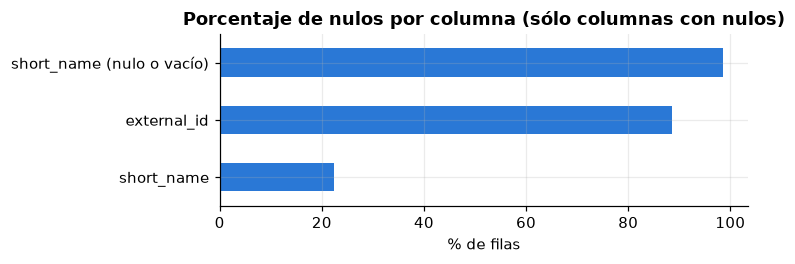

In [13]:
nulos = pd.DataFrame({"nulos": df[COLS].isnull().sum()})
nulos["% nulos"] = (nulos.nulos / len(df) * 100).round(2)
# short_name también viene como string vacío: se cuenta como faltante "oculto"
vacios = (df.short_name.isna() | df.short_name.astype(str).str.strip().isin(["", "nan"])).sum()
nulos.loc["short_name (nulo o vacío)"] = [vacios, round(vacios / len(df) * 100, 2)]
nulos = nulos.sort_values("% nulos", ascending=False)
display(nulos)

ax = nulos["% nulos"][nulos["% nulos"] > 0].plot.barh(color=BLUE, figsize=(7, 2.5))
ax.set(xlabel="% de filas", title="Porcentaje de nulos por columna (sólo columnas con nulos)")
ax.invert_yaxis()
plt.tight_layout()

In [14]:
(df.groupby(df.ts.dt.to_period("M")).external_id.apply(lambda s: s.notna().mean() * 100)
   .round(1).loc["2026-01":].to_frame("% external_id no nulo").T)

ts,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
% external_id no nulo,0.0,0.0,0.0,100.0,100.0,100.0,100.0,100.0,100.0


In [15]:
tcols = TRIP_KEEP + ["duracion_s"]
nulos_tr = tr[tcols].isnull().groupby(tr.anio_archivo).mean().mul(100).T.round(2)
nulos_tr.insert(0, "nulos (total)", tr[tcols].isnull().sum())
display(nulos_tr[nulos_tr["nulos (total)"] > 0])
print("Viajes con fecha_destino nula por año:", tr.fecha_destino.isna().groupby(tr.anio_archivo).sum().to_dict())

anio_archivo,nulos (total),2024,2025,2026
nombre_estacion_origen,22,0.00,0.00,0.0
fecha_destino,3379,0.09,0.00,0.0
id_estacion_destino,2,0.00,0.00,0.0
genero,20547,0.34,0.27,0.0


Viajes con fecha_destino nula por año: {2024: 3379, 2025: 0, 2026: 0}


`external_id` es nulo hasta marzo de 2026 y pasa a estar completo desde el 2026-04 (UUIDs): el proveedor cambió
el esquema del feed en abril de 2026. `short_name` tiene nulos (22 %) y además strings vacíos: 99 % faltante real.

Las columnas de medición están completas: los faltantes reales de este dataset **no son celdas nulas sino
fotos que no existen**. Para verlos hay que armar la grilla estación × hora.

### 3.2 Grilla estación × hora (`missingno.matrix`)

Cada fila es una hora (de la primera a la última foto), cada columna una estación; la celda es nula si esa estación
no tiene ninguna foto en esa hora.

Celdas con foto: 75.0% de 8,939,916


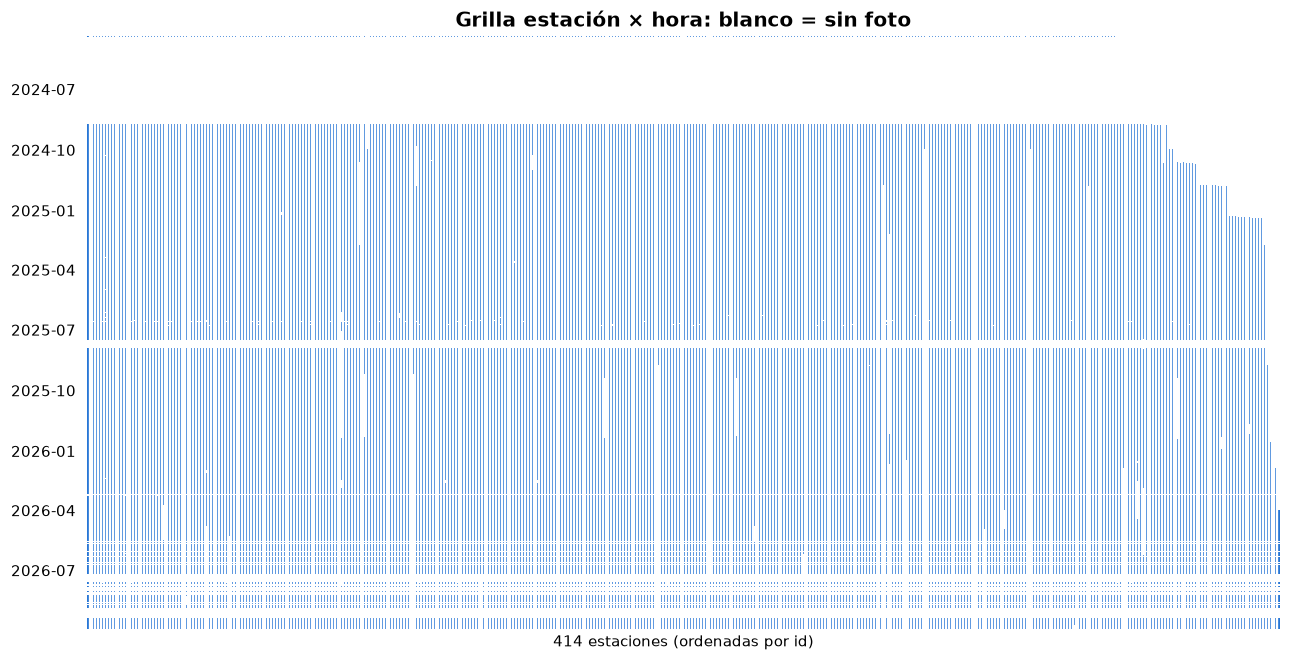

In [16]:
hours = pd.date_range(df.hour.min(), df.hour.max(), freq="h")
grilla = (df.groupby(["hour", "station_id"], observed=True).size()
            .unstack().reindex(hours))
grilla.index = grilla.index.tz_localize(None)
order = sorted(grilla.columns, key=lambda s: int(s) if s.isdigit() else 10**6)
ax = msno.matrix(grilla[order], sparkline=False, figsize=(14, 7), fontsize=8, color=(0.16, 0.47, 0.84))
ticks = pd.date_range(grilla.index.min().normalize(), grilla.index.max(), freq="QS")
ax.set_yticks([grilla.index.get_indexer([t], method="nearest")[0] for t in ticks])
ax.set_yticklabels([f"{t:%Y-%m}" for t in ticks])
ax.set_xticks([])
ax.set_xlabel(f"{grilla.shape[1]} estaciones (ordenadas por id)")
ax.set_title("Grilla estación × hora: blanco = sin foto", fontsize=13, fontweight="bold")
print(f"Celdas con foto: {grilla.notna().mean().mean():.1%} de {grilla.size:,}")

In [17]:
fotos = pd.Series(np.sort(df.committed_at_utc.unique())).dt.tz_convert(TZ)
gaps = pd.DataFrame({"desde": fotos.shift(), "hasta": fotos, "horas": fotos.diff().dt.total_seconds() / 3600})
huecos = gaps[gaps.horas > 3].sort_values("horas", ascending=False)
print(f"Huecos > 3 h entre fotos: {len(huecos)} · {huecos.horas.sum():,.0f} horas en total")
huecos.head(10).round({"horas": 1})

Huecos > 3 h entre fotos: 118 · 3,947 horas en total


,desde,hasta,horas
158,2024-04-12 11:48:40-03:00,2024-08-22 11:48:42-03:00,3168.0
28477,2025-07-16 14:48:21-03:00,2025-07-28 05:33:31-03:00,278.8
51637,2026-08-27 00:19:22-03:00,2026-08-27 11:28:54-03:00,11.2
51640,2026-08-28 07:00:44-03:00,2026-08-28 18:09:56-03:00,11.2
51639,2026-08-27 20:54:14-03:00,2026-08-28 07:00:44-03:00,10.1
51638,2026-08-27 11:28:54-03:00,2026-08-27 20:54:14-03:00,9.4
51001,2026-08-06 12:41:57-03:00,2026-08-06 21:40:26-03:00,9.0
51655,2026-08-31 03:16:45-03:00,2026-08-31 11:03:50-03:00,7.8
51642,2026-08-29 00:10:55-03:00,2026-08-29 07:05:21-03:00,6.9
51656,2026-08-31 11:03:50-03:00,2026-08-31 17:05:38-03:00,6.0


,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
% horas con foto,8.6,0.0,0.0,0.0,30.8,100.0,100.0,100.0,100.0,99.7,100.0,100.0,100.0,99.9,100.0,58.9,99.7,100.0,100.0,100.0,100.0,99.7,96.4,97.0,97.1,90.1,79.6,56.5,70.0,74.2
intervalo mediano (min),15.0,NaN,NaN,NaN,15.2,15.3,15.3,15.5,15.4,15.4,15.4,15.7,15.7,15.5,15.6,20.8,15.6,15.7,15.8,15.8,15.7,15.9,24.2,24.4,30.3,42.6,57.1,89.8,42.9,12.0


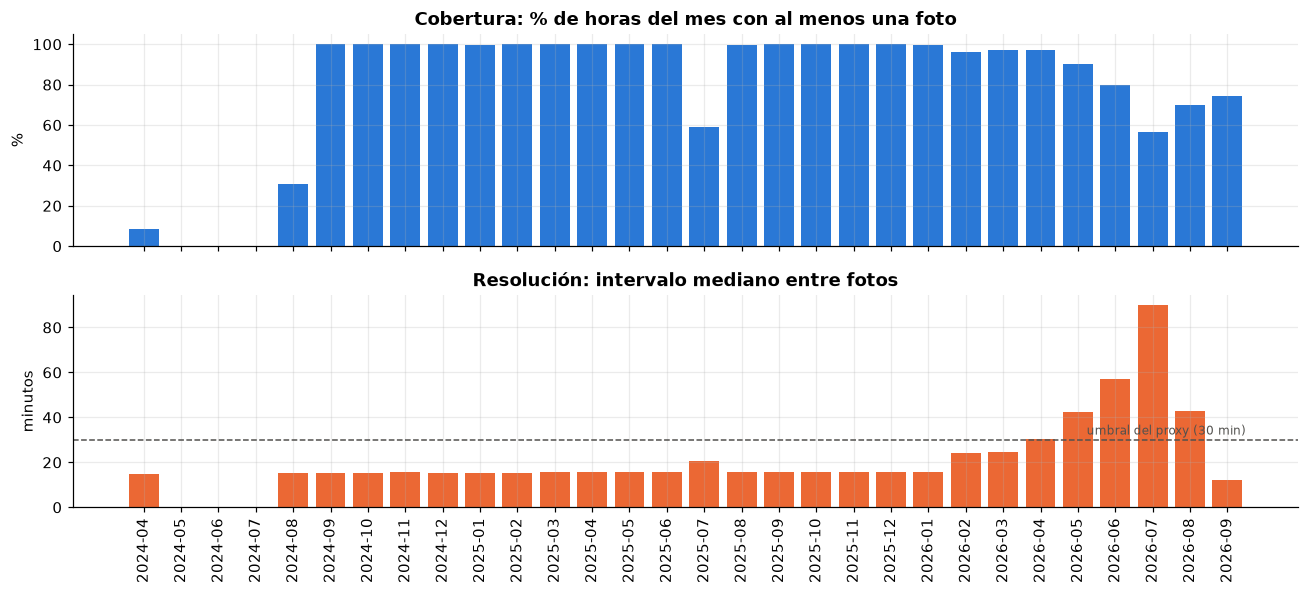

In [18]:
fotos_m = pd.DataFrame({"ts": fotos, "gap": fotos.diff().dt.total_seconds() / 60})
cob = pd.DataFrame({
    "% horas con foto": pd.Series(1, index=fotos.dt.floor("h").unique()).reindex(pd.DatetimeIndex(hours))
                           .notna().groupby(hours.to_period("M")).mean().mul(100),
    "intervalo mediano (min)": fotos_m.groupby(fotos_m.ts.dt.to_period("M")).gap.median(),
}).round(1)

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
x = cob.index.astype(str)
axes[0].bar(x, cob["% horas con foto"], color=BLUE, width=0.8)
axes[0].set(ylabel="%", title="Cobertura: % de horas del mes con al menos una foto")
axes[1].bar(x, cob["intervalo mediano (min)"], color=ORANGE, width=0.8)
axes[1].axhline(30, color="#52514e", ls="--", lw=1)
axes[1].text(len(x) - 0.5, 31, "umbral del proxy (30 min)", ha="right", va="bottom", fontsize=8, color="#52514e")
axes[1].set(ylabel="minutos", title="Resolución: intervalo mediano entre fotos")
plt.xticks(rotation=90)
plt.tight_layout()
cob.T

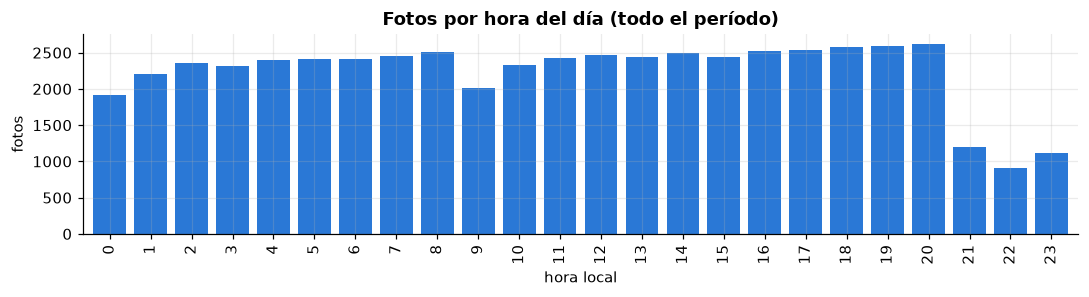

In [19]:
por_hora = fotos.dt.hour.value_counts().sort_index()
ax = por_hora.plot.bar(color=BLUE, figsize=(10, 2.8), width=0.8)
ax.set(xlabel="hora local", ylabel="fotos", title="Fotos por hora del día (todo el período)")
plt.tight_layout()

**Lectura.**
- **Abril–agosto 2024**: hueco de 132 días (12/04 → 22/08/2024) — banda blanca completa.
- **Julio 2025**: 16/07 → 28/07/2025 sin fotos (279 h).
- **2026**: no es un hueco único sino **degradación de la resolución**: el intervalo mediano pasa de ~16 min a 24 (feb–mar),
  30 (abr), 43 (may), 57 (jun) y 90 min (jul), con decenas de huecos de 5–11 h en agosto–septiembre.
- **Noche**: entre las 21 y las 23 h hay la mitad de fotos que el resto del día (patrón del scraper, no de la red).
- Las columnas que empiezan tarde o terminan antes son altas y bajas de estaciones.

## 4. Duplicados

Viajes por `id_recorrido` (una vez quitado el sufijo `BAEcobici`), fotos por `(estación, foto)` y estabilidad de los
atributos de cada estación, que es donde aparecen los “duplicados lógicos”.

In [20]:
dup_tr = pd.DataFrame({
    "viajes": tr.groupby("anio_archivo").size(),
    "id_recorrido duplicado (dentro del año)": tr.groupby("anio_archivo").id_recorrido.apply(lambda s: s.duplicated().sum()),
    "filas duplicadas exactas": tr.groupby("anio_archivo").apply(lambda t: t.duplicated(TRIP_KEEP).sum(), include_groups=False),
})
print("id_recorrido repetido entre años:",
      tr.id_recorrido.duplicated().sum() - dup_tr["id_recorrido duplicado (dentro del año)"].sum())
display(dup_tr)
tr[tr.id_recorrido.duplicated(keep=False)].sort_values("id_recorrido")[TRIP_KEEP]

id_recorrido repetido entre años: 0


,viajes,id_recorrido duplicado (dentro del año),filas duplicadas exactas
anio_archivo,,,
2024,3559284,1,1
2025,3156182,0,0
2026,1979625,0,0


,id_recorrido,duracion_recorrido,fecha_origen,id_estacion_origen,nombre_estacion_origen,fecha_destino,id_estacion_destino,id_usuario,modelo_bicicleta,genero
434350,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,2024-07-23 12:49:09,402,1039158,FIT,MALE
434351,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,2024-07-23 12:49:09,402,1039158,FIT,MALE


In [21]:
ids_fotos = set(df.station_id.astype(str).unique())
sin_foto = ~tr.id_estacion_origen.astype(str).isin(ids_fotos)
print(f"Viajes cuya estación de origen no aparece en las fotos: {sin_foto.sum():,} "
      f"({tr.loc[sin_foto, 'id_estacion_origen'].nunique()} estaciones)")
print(f"Estaciones de viajes: {tr.id_estacion_origen.nunique()} · de fotos: {len(ids_fotos)}")

Viajes cuya estación de origen no aparece en las fotos: 1,163 (1 estaciones)
Estaciones de viajes: 414 · de fotos: 414


In [22]:
dup = pd.Series({
    "filas duplicadas exactas": df.duplicated(subset=COLS).sum(),
    "duplicados por (station_id, foto)": df.duplicated(["station_id", "committed_at_utc"]).sum(),
    "estaciones con > 1 nombre": (df.groupby("station_id", observed=True).name.nunique() > 1).sum(),
    "estaciones con > 1 coordenada": (df.groupby("station_id", observed=True)[["latitude", "longitude"]]
                                      .nunique().gt(1).any(axis=1)).sum(),
    "estaciones con > 1 capacidad": (df.groupby("station_id", observed=True).capacity.nunique() > 1).sum(),
    "nombres usados por > 1 station_id": (df.groupby("name", observed=True).station_id.nunique() > 1).sum(),
    "clima: filas con forecast_at_utc repetido": w.forecast_at_utc.duplicated().sum(),
    "clima: filas duplicadas por (forecast_at, descarga)": w.duplicated(["forecast_at_utc", "committed_at_utc"]).sum(),
})
dup.to_frame("cantidad")

,cantidad
filas duplicadas exactas,0
"duplicados por (station_id, foto)",0
estaciones con > 1 nombre,6
estaciones con > 1 coordenada,175
estaciones con > 1 capacidad,366
nombres usados por > 1 station_id,2
clima: filas con forecast_at_utc repetido,104856
"clima: filas duplicadas por (forecast_at, descarga)",0


In [23]:
renombres = (df.groupby(["station_id", "name"], observed=True).ts.agg(["min", "max", "size"])
               .loc[lambda t: t.index.get_level_values(0).isin(
                   df.groupby("station_id", observed=True).name.nunique().loc[lambda s: s > 1].index)])
renombres

min                       max   size
station_id name                                                                                            
307        341 - COMUNA 4                        2024-04-10 18:45:34-03:00 2025-08-09 07:24:51-03:00  29457
           341 - EDITORIAL PERFIL                2025-08-09 07:39:00-03:00 2025-08-22 17:07:19-03:00   1138
358        249 - Balbín                          2024-04-10 18:45:34-03:00 2024-04-12 11:48:40-03:00    158
           249 - Vidal                           2024-08-22 11:48:42-03:00 2026-09-27 11:01:36-03:00  53535
449        352 - Papa Francisco                  2025-04-29 10:53:00-03:00 2026-09-27 11:01:36-03:00  31393
           352 - San Jose de Flores              2024-04-10 18:45:34-03:00 2025-04-29 10:32:08-03:00  22259
497        307 - CERETTI                         2026-03-17 13:09:53-03:00 2026-09-27 11:01:36-03:00   5582
           307 - CERRETTI                        2024-04-10 18:45:34-03:00 2026-03-17 12:39:31-03:00  46861
541        198 - AEROPARQUE                      2024-08-22 11:48:42-03:00 2026-01-26 09:14:30-03:00  43744
           198 - CENTRO METROPOLITANO DE DISEÑO  2026-01-26 15:28:16-03:00 2026-01-26 15:28:16-03:00      1
           198 - centro metropolitano de diseño  2026-01-26 14:43:37-03:00 2026-01-26 15:11:58-03:00      3
546        143 - COMUNA 7                        2024-08-22 11:48:42-03:00 2026-02-15 18:41:21-03:00  44672
           143 - EMILIO MITRE                    2026-04-13 16:12:50-03:00 2026-09-27 11:01:36-03:00   5481

In [24]:
cap = df.groupby("station_id", observed=True).capacity.agg(["min", "max", "nunique"])
en_caba = df.latitude.between(-34.75, -34.5) & df.longitude.between(-58.55, -58.33)
fuera = df[~en_caba]
print(f"Filas con coordenadas fuera de CABA: {len(fuera):,} · estaciones: {fuera.station_id.nunique()}")
display(fuera.groupby(["station_id", "name", "latitude", "longitude"], observed=True).ts.agg(["min", "max", "size"]))

mov = df[en_caba].groupby("station_id", observed=True).agg(lat_min=("latitude", "min"), lat_max=("latitude", "max"),
                                                  lon_min=("longitude", "min"), lon_max=("longitude", "max"))
mov["desplazamiento_m"] = np.hypot((mov.lat_max - mov.lat_min) * 111_000,
                                   (mov.lon_max - mov.lon_min) * 111_000 * np.cos(np.radians(34.6)))
print("Rango de capacidad por estación (max − min):")
print((cap["max"] - cap["min"]).describe().round(1).to_dict())
print("Desplazamiento máximo de coordenadas dentro de CABA (m), estaciones que se movieron:")
print(mov.desplazamiento_m[mov.desplazamiento_m > 0].describe(percentiles=[.5, .9]).round(0).to_dict())

Filas con coordenadas fuera de CABA: 5,265 · estaciones: 1


,,,,min,max,size
station_id,name,latitude,longitude,,,
66,066 - Billinghurst,34.594547,-58.413871,2024-10-14 23:12:53-03:00,2024-12-13 12:06:22-03:00,5265


Rango de capacidad por estación (max − min):
{'count': 414.0, 'mean': 12.8, 'std': 9.5, 'min': 0.0, '25%': 1.0, '50%': 16.0, '75%': 20.0, 'max': 40.0}
Desplazamiento máximo de coordenadas dentro de CABA (m), estaciones que se movieron:
{'count': 174.0, 'mean': 63.0, 'std': 303.0, 'min': 0.0, '50%': 0.0, '90%': 173.0, 'max': 3628.0}


**Lectura.** En viajes hay un único `id_recorrido` repetido (2024) y ningún ID repetido entre años; los `id_estacion`
de BA Data coinciden con los `station_id` del feed una vez quitado el sufijo, así que ambas fuentes se pueden cruzar.
No hay duplicados por `(estación, foto)`. Los problemas de las fotos son de identidad: 6 estaciones cambian de nombre
(p. ej. *352 San José de Flores → Papa Francisco*), dos nombres (*341 – Editorial Perfil* y
*198 – Centro Metropolitano de Diseño*) corresponden cada uno a dos `station_id`. 175 estaciones cambian de coordenadas,
aunque la mayoría por diferencias de redondeo (< 1 m); el 10 % se mueve más de ~170 m y el máximo es 3,6 km.
366 estaciones cambian de capacidad, con un rango mediano de 16 docks: `capacity` no es un atributo fijo. La estación **066 – Billinghurst** tiene la **latitud con el signo invertido**
(+34,59 en vez de −34,59) entre octubre y diciembre de 2024: queda en el hemisferio norte, a ~7.700 km.
**Hay que modelar por `station_id`, no por nombre.** El clima trae ~7 pronósticos por hora pronosticada
(cada descarga re-pronostica ±24 h): hay que quedarse con uno (p. ej. el más cercano a la hora real).

## 5. Outliers

### 5.1 Duración de los viajes (escala logarítmica) y límites por IQR

El IQR se calcula sobre la duración cruda y sobre `log10(duración)`: la distribución es muy asimétrica y el IQR en
escala lineal no tiene límite inferior útil.

,límite inferior (s),límite superior (s),% viajes debajo,% viajes encima
IQR lineal,-945.00,3047.00,0.00,5.82
IQR sobre log10,117.31,7293.24,4.59,0.77


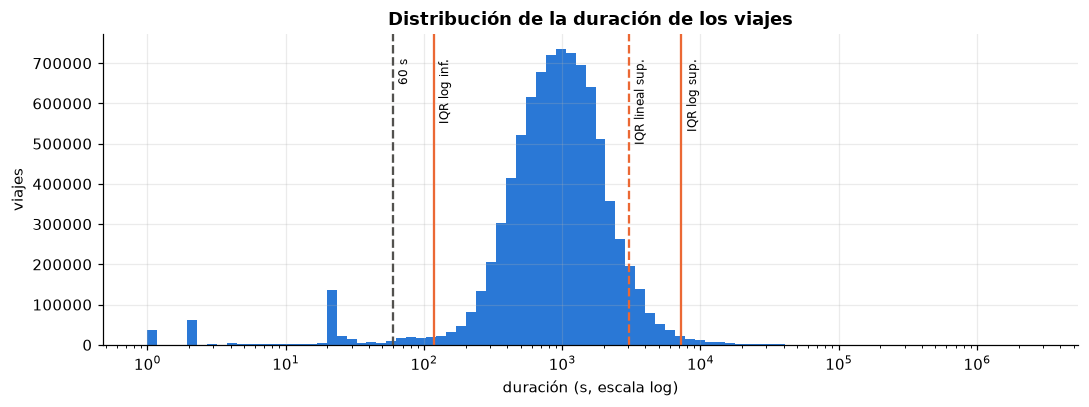

In [25]:
dur = tr.duracion_s[tr.duracion_s > 0]
q1, q3 = dur.quantile([.25, .75])
lim_lin = (q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1))
lq1, lq3 = np.log10(dur).quantile([.25, .75])
lim_log = (10 ** (lq1 - 1.5 * (lq3 - lq1)), 10 ** (lq3 + 1.5 * (lq3 - lq1)))
d = tr.duracion_s
iqr_tab = pd.DataFrame({
    "límite inferior (s)": [lim_lin[0], lim_log[0]],
    "límite superior (s)": [lim_lin[1], lim_log[1]],
    "% viajes debajo": [(d < lim_lin[0]).mean() * 100, (d < lim_log[0]).mean() * 100],
    "% viajes encima": [(d > lim_lin[1]).mean() * 100, (d > lim_log[1]).mean() * 100],
}, index=["IQR lineal", "IQR sobre log10"]).round(2)
display(iqr_tab)

fig, ax = plt.subplots(figsize=(10, 3.8))
bins = np.logspace(0, np.log10(d.max()), 90)
ax.hist(d.clip(lower=1), bins=bins, color=BLUE)
ax.set_xscale("log")
for v, lab in [(lim_log[0], "IQR log inf."), (lim_log[1], "IQR log sup."), (lim_lin[1], "IQR lineal sup."), (60, "60 s")]:
    ax.axvline(v, color=ORANGE if "IQR" in lab else "#52514e", lw=1.5, ls="-" if "log" in lab else "--")
    ax.text(v * 1.08, ax.get_ylim()[1] * 0.92, lab, fontsize=8, rotation=90, va="top")
ax.set(xlabel="duración (s, escala log)", ylabel="viajes", title="Distribución de la duración de los viajes")
plt.tight_layout()

### 5.2 Viajes de menos de 60 s por año

,viajes,duracion_min_s,pct_0s,pct_menos_60s,pct_menos_120s
anio_archivo,,,,,
2024,3559284,0,1.06,9.11,9.88
2025,3156182,61,0.00,0.00,0.94
2026,1979625,61,0.00,0.00,0.99


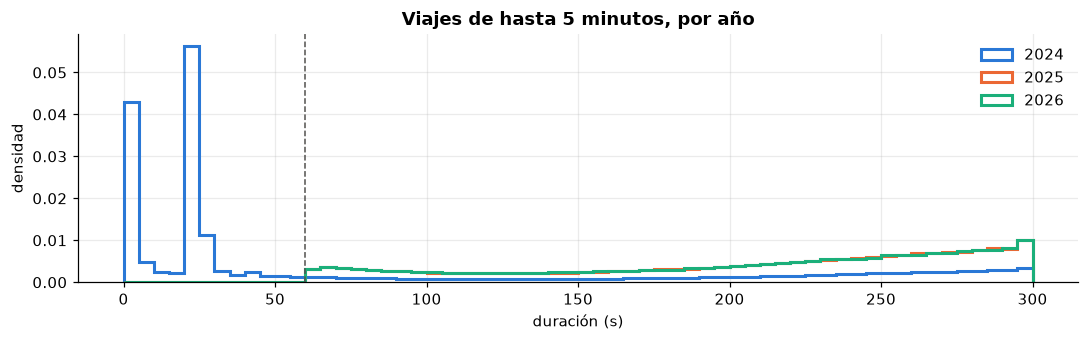

In [26]:
cortos = tr.groupby("anio_archivo").agg(
    viajes=("duracion_s", "size"),
    duracion_min_s=("duracion_s", "min"),
    pct_0s=("duracion_s", lambda s: (s == 0).mean() * 100),
    pct_menos_60s=("duracion_s", lambda s: (s < 60).mean() * 100),
    pct_menos_120s=("duracion_s", lambda s: (s < 120).mean() * 100),
).round(2)
display(cortos)

fig, ax = plt.subplots(figsize=(10, 3.2))
for anio, c in zip(sorted(tr.anio_archivo.unique()), [BLUE, ORANGE, AQUA]):
    s = tr.duracion_s[(tr.anio_archivo == anio) & (tr.duracion_s <= 300)]
    ax.hist(s, bins=range(0, 301, 5), histtype="step", lw=2, color=c, label=str(anio), density=True)
ax.axvline(60, color="#52514e", ls="--", lw=1)
ax.set(xlabel="duración (s)", ylabel="densidad", title="Viajes de hasta 5 minutos, por año")
ax.legend(frameon=False)
plt.tight_layout()

**Evidencia de que BA Data limpió distinto según el año:** en 2024 ~9 % de los viajes dura menos de 60 s (incluidos
viajes de 0 s), mientras que desde 2025 **no hay ningún viaje de menos de 61 s**: el publicador empezó a filtrarlos.
Para comparar años hay que aplicar el mismo corte (descartar < 61 s en 2024).

### 5.3 Viajes que vuelven a la misma estación en menos de 2 minutos

In [27]:
misma = tr.id_estacion_origen.astype(str) == tr.id_estacion_destino.astype(str)
vuelta = pd.DataFrame({
    "% misma estación": misma.groupby(tr.anio_archivo).mean() * 100,
    "% misma estación y < 2 min": (misma & (tr.duracion_s < 120)).groupby(tr.anio_archivo).mean() * 100,
    "viajes misma estación y < 2 min": (misma & (tr.duracion_s < 120)).groupby(tr.anio_archivo).sum(),
    "% de esos que además duran < 61 s": (misma & (tr.duracion_s < 61)).groupby(tr.anio_archivo).sum()
                                         / (misma & (tr.duracion_s < 120)).groupby(tr.anio_archivo).sum() * 100,
}).round(2)
vuelta

,% misma estación,% misma estación y < 2 min,viajes misma estación y < 2 min,% de esos que además duran < 61 s
anio_archivo,,,,
2024,13.47,7.26,258520,90.22
2025,8.74,0.90,28428,0.00
2026,9.12,0.95,18777,0.00


Retirar y devolver en la misma estación en menos de 2 min no es un viaje: es una bici que el usuario rechaza
(rota, asiento, etc.) o un error de anclaje. En 2024 son ~7 % de los viajes; desde 2025 bajan a < 1 % porque
la mayoría caía debajo del corte de 60 s. **Se recomienda descartarlos en todos los años.**

### 5.4 Outliers en el proxy de retiros (fotos)

Retiros por estación-hora: Q1=0, Q3=1, IQR=1, límite superior=2.5
Outliers por IQR: 5.8% de las estación-hora


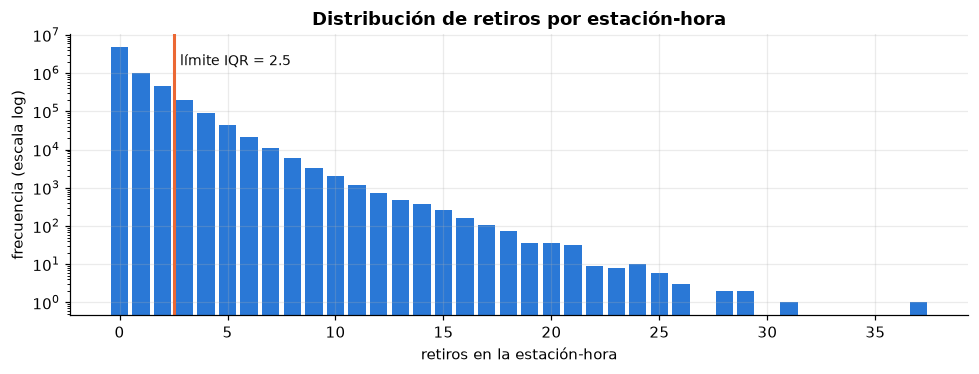

In [28]:
q1, q3 = sh.retiros.quantile([.25, .75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"Retiros por estación-hora: Q1={q1:.0f}, Q3={q3:.0f}, IQR={iqr:.0f}, límite superior={upper:.1f}")
print(f"Outliers por IQR: {(sh.retiros > upper).mean():.1%} de las estación-hora")

fig, ax = plt.subplots(figsize=(9, 3.5))
counts = sh.retiros.value_counts().sort_index()
ax.bar(counts.index, counts.values, color=BLUE, width=0.8)
ax.set_yscale("log")
ax.axvline(upper, color=ORANGE, lw=2)
ax.text(upper + 0.3, counts.max() / 3, f"límite IQR = {upper:.1f}", color="#0b0b0b", fontsize=9)
ax.set(xlabel="retiros en la estación-hora", ylabel="frecuencia (escala log)",
       title="Distribución de retiros por estación-hora")
plt.tight_layout()

Con Q1 = 0 y Q3 = 1 el criterio IQR marca como outlier cualquier hora con ≥ 3 retiros: es demasiado agresivo para
conteos con exceso de ceros. Conviene un criterio por estación (p. ej. percentil 99,9 de su propia distribución) o
directamente filtrar los **saltos de rebalanceo**.

In [29]:
jump = df.delta.where(valid).abs()
rebal = df[jump >= 10]
print(f"Saltos de ≥ 10 bicis en ≤ 30 min: {len(rebal):,} "
      f"({rebal.delta.lt(0).sum():,} bajadas, {rebal.delta.gt(0).sum():,} subidas) "
      f"en {rebal.station_id.nunique()} estaciones")
print(f"Retiros explicados por bajadas ≥ 10: {(-rebal.delta[rebal.delta < 0]).sum() / df.retiros.sum():.2%} del total")
rebal.groupby("name", observed=True).size().nlargest(10).to_frame("saltos ≥ 10")

Saltos de ≥ 10 bicis en ≤ 30 min: 6,199 (1,377 bajadas, 4,822 subidas) en 366 estaciones
Retiros explicados por bajadas ≥ 10: 0.49% del total


,saltos ≥ 10
name,
147 - Constitución,181
104 - Federico Lacroze,156
094 - GÚZMAN,123
014 - Pacifico,108
130 - RETIRO II,103
025 - Plaza Guemes,97
029 - Parque Centenario,84
300 - Jose Artigas,81
152 - JULIETA LANTERI,75


Los saltos son mayormente **subidas** (reposición con camión); las bajadas masivas explican < 1 % de los retiros
estimados, así que el rebalanceo casi no infla el proxy de retiros pero sí el de devoluciones.

In [30]:
anual = df.assign(año=df.ts.dt.year).groupby("año").agg(
    intervalo_mediano_min=("gap_min", "median"),
    pct_intervalos_le_30=("gap_min", lambda s: (s <= 30).mean() * 100),
    pct_intervalos_con_caida=("delta", lambda s: (s < 0).mean() * 100),
).round(1)
anual

,intervalo_mediano_min,pct_intervalos_le_30,pct_intervalos_con_caida
año,,,
2024,15.4,96.3,14.1
2025,15.8,94.4,12.9
2026,23.4,65.1,16.8


**Las fotos también cambian según el año:** en 2026
sólo una parte de los intervalos cumple el umbral de 30 min, así que el proxy de 2026 no es comparable con 2024–2025
sin corregir por resolución (ver sección 6.1 y 8).

In [31]:
tot = df.num_bikes_available + df.num_bikes_disabled + df.num_docks_available + df.num_docks_disabled
consist = pd.Series({
    "bicis + docks = capacidad (%)": (tot == df.capacity).mean() * 100,
    "bicis + docks > capacidad (%)": (tot > df.capacity).mean() * 100,
    "bicis + docks < capacidad (%)": (tot < df.capacity).mean() * 100,
    "filas con capacity = 0": (df.capacity == 0).sum(),
    "filas con disponibles > capacidad": (df.num_bikes_available > df.capacity).sum(),
    "valores negativos": int((df[INTS] < 0).sum().sum()),
    "fotos con estación vacía (%)": (df.num_bikes_available == 0).mean() * 100,
    "fotos con estación llena (%)": (df.num_docks_available == 0).mean() * 100,
}).round(2)
consist.to_frame("valor")

,valor
bicis + docks = capacidad (%),93.26
bicis + docks > capacidad (%),6.72
bicis + docks < capacidad (%),0.02
filas con capacity = 0,7208.00
filas con disponibles > capacidad,11.00
valores negativos,0.00
fotos con estación vacía (%),12.54
fotos con estación llena (%),3.16


## 6. Visualizaciones iniciales

### 6.1 Retiros por mes (estacionalidad)

Viajes reales de BA Data (sin los < 61 s ni las vueltas a la misma estación en < 2 min, para que los años sean
comparables) contra dos versiones del proxy, normalizadas por días con datos: umbral 30 min (el principal) y 180 min.
Las secciones 6.2–6.5 usan el proxy, que es el target del modelo.

,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03,...,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
dias,NaN,NaN,NaN,3.0,NaN,NaN,NaN,10.0,30.0,31.0,30.0,31.0,31.0,28.0,31.0,...,20.0,31.0,30.0,31.0,30.0,31.0,31.0,28.0,31.0,30.0,31.0,30.0,31.0,31.0,27.0
retiros_30,NaN,NaN,NaN,13257.0,NaN,NaN,NaN,44530.0,198945.0,210483.0,201086.0,192643.0,197311.0,172193.0,184220.0,...,65578.0,151164.0,185213.0,207561.0,183983.0,171786.0,171926.0,109314.0,121936.0,65985.0,19295.0,4120.0,102.0,13592.0,110315.0
retiros_180,NaN,NaN,NaN,13863.0,NaN,NaN,NaN,46908.0,209858.0,222383.0,214210.0,206432.0,211608.0,184655.0,199485.0,...,87040.0,166494.0,197687.0,223504.0,201854.0,191687.0,197188.0,163061.0,182582.0,147848.0,121276.0,97455.0,72840.0,84206.0,121634.0
por_dia_30,NaN,NaN,NaN,4419.0,NaN,NaN,NaN,4453.0,6632.0,6790.0,6703.0,6214.0,6365.0,6150.0,5943.0,...,3279.0,4876.0,6174.0,6696.0,6133.0,5541.0,5546.0,3904.0,3933.0,2200.0,622.0,137.0,3.0,438.0,4086.0
por_dia_180,NaN,NaN,NaN,4621.0,NaN,NaN,NaN,4691.0,6995.0,7174.0,7140.0,6659.0,6826.0,6595.0,6435.0,...,4352.0,5371.0,6590.0,7210.0,6728.0,6183.0,6361.0,5824.0,5890.0,4928.0,3912.0,3248.0,2350.0,2716.0,4505.0
viajes_por_dia,8656.0,8689.0,9205.0,8430.0,7744.0,7250.0,6896.0,7070.0,10383.0,10722.0,10649.0,9566.0,9628.0,9215.0,9236.0,...,5673.0,7287.0,9557.0,11007.0,10185.0,8936.0,9543.0,9984.0,10129.0,8692.0,7471.0,6447.0,5935.0,6507.0,NaN


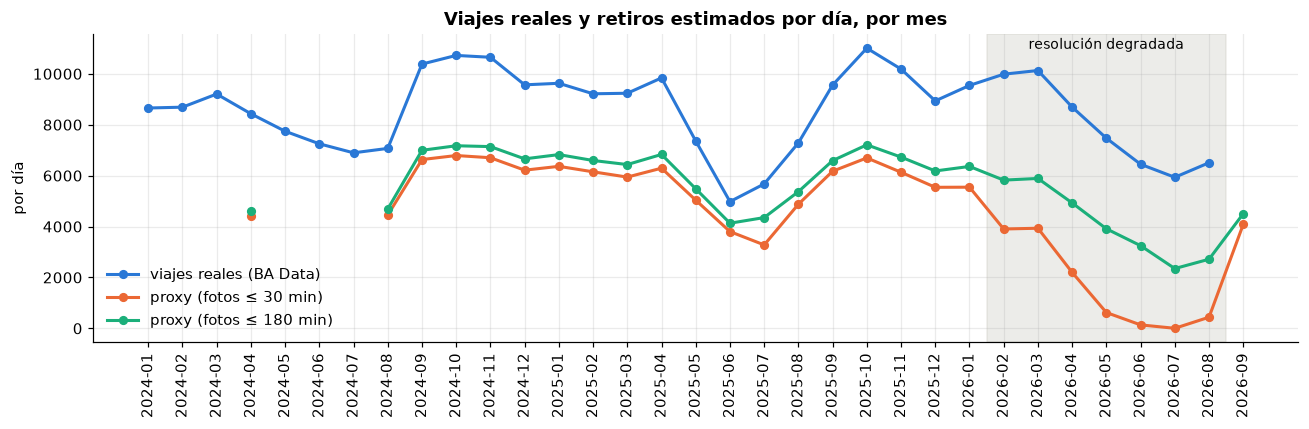

In [32]:
p180 = (-df.delta).clip(lower=0).where(df.gap_min <= 180, 0)
mes = df.ts.dt.to_period("M")
mensual = pd.DataFrame({
    "dias": df.groupby(mes).ts.agg(lambda s: s.dt.date.nunique()),
    "retiros_30": df.groupby(mes).retiros.sum(),
    "retiros_180": p180.groupby(mes).sum(),
})
mensual["por_dia_30"] = mensual.retiros_30 / mensual.dias
mensual["por_dia_180"] = mensual.retiros_180 / mensual.dias

validos = (tr.duracion_s >= 61) & ~(misma & (tr.duracion_s < 120))
tv = tr[validos]
vmes = tv.groupby(tv.fecha_origen.dt.to_period("M")).agg(viajes=("id_recorrido", "size"),
                                                         dias=("fecha_origen", lambda s: s.dt.date.nunique()))
vmes["por_dia"] = vmes.viajes / vmes.dias
mensual = mensual.join(vmes.por_dia.rename("viajes_por_dia"), how="outer")

fig, ax = plt.subplots(figsize=(12, 4))
x = mensual.index.astype(str)
ax.plot(x, mensual.viajes_por_dia, color=BLUE, lw=2, marker="o", ms=5, label="viajes reales (BA Data)")
ax.plot(x, mensual.por_dia_30, color=ORANGE, lw=2, marker="o", ms=5, label="proxy (fotos ≤ 30 min)")
ax.plot(x, mensual.por_dia_180, color=AQUA, lw=2, marker="o", ms=5, label="proxy (fotos ≤ 180 min)")
ax.axvspan(x.get_loc("2026-02") - 0.5, x.get_loc("2026-08") + 0.5, color="#c3c2b7", alpha=0.3)
ax.text(x.get_loc("2026-05"), ax.get_ylim()[1] * 0.95, "resolución degradada", ha="center", fontsize=9)
ax.set(ylabel="por día", title="Viajes reales y retiros estimados por día, por mes")
ax.legend(frameon=False, loc="lower left")
plt.xticks(rotation=90)
plt.tight_layout()
mensual.round(0).T

- **Estacionalidad real:** ~10.400–11.000 viajes/día en primavera (sep–nov) contra ~5.000–6.900 en junio–julio (invierno),
  con baja en diciembre–enero por vacaciones. Los viajes cubren además abril–julio de 2024, donde no hay fotos.
- **El proxy sigue la forma de la curva pero en otro nivel:** en los meses con buena resolución captura ~60–65 % de los viajes.
- **La caída de 2026 es un artefacto:** los viajes reales de feb–mar 2026 (~10.000/día) están al nivel de 2025, mientras
  que el proxy cae a ~3.900 y llega casi a cero en junio–julio. Septiembre de 2026 todavía no tiene viajes publicados.

### 6.2 Heatmap hora × día de la semana

Sólo días con las 24 horas cubiertas y del período con buena resolución (hasta enero de 2026).

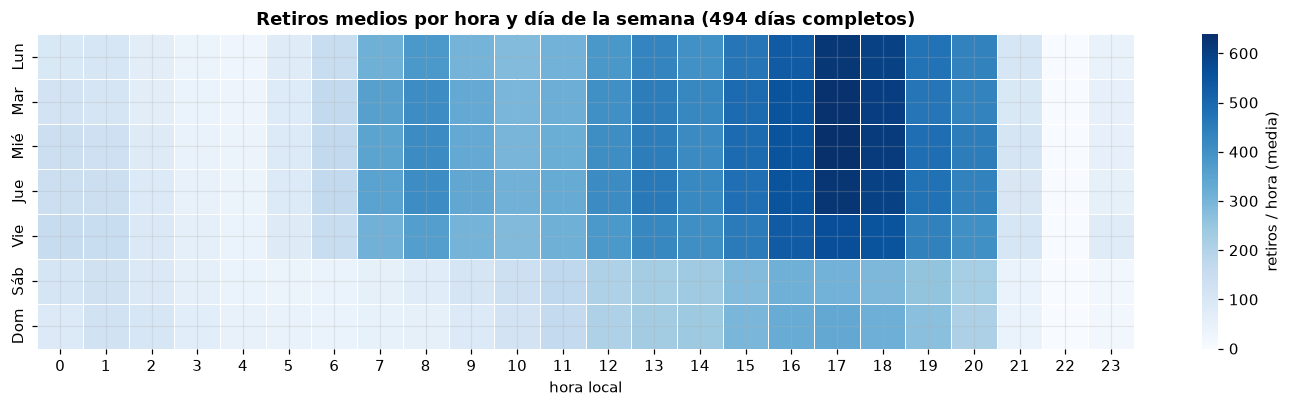

In [33]:
red = df.groupby("hour").retiros.sum().reindex(hours)
red = red[red.index < pd.Timestamp("2026-02-01", tz=TZ)]
horas_por_dia = red.notna().groupby(red.index.date).sum()
dias_completos = horas_por_dia[horas_por_dia == 24].index
red_c = red[np.isin(red.index.date, dias_completos)]

hw = red_c.groupby([red_c.index.dayofweek, red_c.index.hour]).mean().unstack()
hw.index = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
fig, ax = plt.subplots(figsize=(13, 3.8))
sns.heatmap(hw, cmap="Blues", ax=ax, cbar_kws={"label": "retiros / hora (media)"}, linewidths=0.5, linecolor="white")
ax.set(xlabel="hora local", ylabel="", title=f"Retiros medios por hora y día de la semana ({len(dias_completos)} días completos)")
plt.tight_layout()

Días hábiles: doble pico (08 h y 17–18 h, ~630 retiros/h). Fines de semana: un único pico de tarde (16–17 h, ~320/h)
y actividad nocturna mayor sábado y domingo de madrugada. **El “hueco” de las 22 h es un artefacto**: a esa hora hay
pocas fotos y los intervalos superan los 30 min.

### 6.3 Días hábiles vs. fines de semana y feriados

,count,mean,std,min,25%,50%,75%,max
tipo,,,,,,,,
feriado,25.0,3817.0,1176.0,1479.0,3148.0,3877.0,4584.0,6587.0
fin de semana,138.0,3500.0,971.0,478.0,2933.0,3816.0,4115.0,6219.0
hábil,331.0,7053.0,1340.0,676.0,6472.0,7473.0,7994.0,9044.0


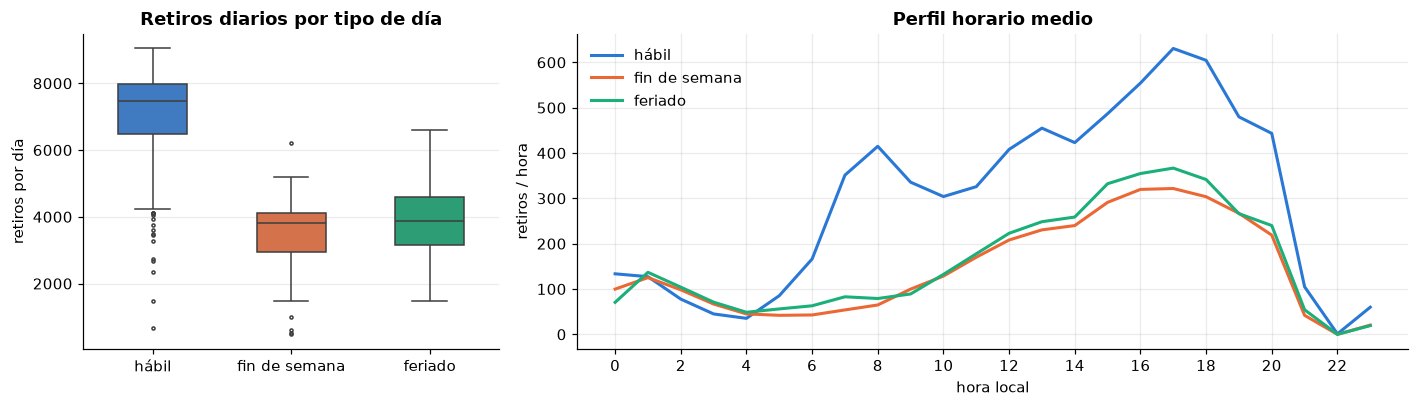

In [34]:
ar = holidays.AR(years=range(2024, 2027))
diario = red_c.groupby(red_c.index.date).sum()
tipo = pd.Series(["feriado" if d in ar else "fin de semana" if pd.Timestamp(d).dayofweek >= 5 else "hábil"
                  for d in diario.index], index=diario.index, name="tipo")
display(diario.groupby(tipo).describe().round(0))

perfil = red_c.groupby([pd.Series(red_c.index.date, index=red_c.index).map(tipo).values, red_c.index.hour]).mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1, 2]})
orden = ["hábil", "fin de semana", "feriado"]
colores = [BLUE, ORANGE, AQUA]
sns.boxplot(x=tipo, y=diario.values, hue=tipo, order=orden, hue_order=orden, palette=colores, legend=False, ax=axes[0], width=0.5, fliersize=2)
axes[0].set(xlabel="", ylabel="retiros por día", title="Retiros diarios por tipo de día")
for t, c in zip(orden, colores):
    axes[1].plot(perfil.columns, perfil.loc[t], color=c, lw=2, label=t)
axes[1].set(xlabel="hora local", ylabel="retiros / hora", title="Perfil horario medio", xticks=range(0, 24, 2))
axes[1].legend(frameon=False)
plt.tight_layout()

Un día hábil tiene ~2× los retiros de un fin de semana. **Los feriados se comportan como fines de semana**
(mismo nivel y mismo perfil de un solo pico), así que conviene una variable `dia_no_laborable` que los agrupe.

### 6.4 Mapa de calor de retiros por estación (`folium`)

In [35]:
est = df.groupby("station_id", observed=True).agg(
    nombre=("name", "last"), lat=("latitude", "last"), lon=("longitude", "last"),
    retiros=("retiros", "sum"), dias=("ts", lambda s: s.dt.date.nunique()))
est["retiros_dia"] = est.retiros / est.dias
est = est[est.lat.between(-34.75, -34.5) & est.lon.between(-58.55, -58.33)]

m = folium.Map(location=[-34.605, -58.43], zoom_start=12, tiles="OpenStreetMap")
HeatMap(est[["lat", "lon", "retiros_dia"]].values.tolist(), radius=14, blur=18,
        max_zoom=13).add_to(m)
for _, r in est.nlargest(10, "retiros_dia").iterrows():
    folium.CircleMarker([r.lat, r.lon], radius=4, color="#0b0b0b", weight=1, fill=True,
                        tooltip=f"{r.nombre}: {r.retiros_dia:.1f} retiros/día").add_to(m)
m.save("mapa_retiros.html")
display(est.sort_values("retiros_dia", ascending=False).head(10).round(1))
m

,nombre,lat,lon,retiros,dias,retiros_dia
station_id,,,,,,
14,014 - Pacifico,-34.6,-58.4,24869.0,759,32.8
516,368 - PLAZA DE LA SHOÁ,-34.6,-58.4,23769.0,759,31.3
175,147 - Constitución,-34.6,-58.4,23424.0,759,30.9
152,152 - JULIETA LANTERI,-34.6,-58.4,22937.0,759,30.2
29,029 - Parque Centenario,-34.6,-58.4,20800.0,759,27.4
130,130 - RETIRO II,-34.6,-58.4,20647.0,759,27.2
150,150 - RODRIGO BUENO,-34.6,-58.4,17981.0,664,27.1
202,001 - FACULTAD DE DERECHO,-34.6,-58.4,20413.0,759,26.9
289,255 - BARRANCAS DE BELGRANO,-34.6,-58.4,20335.0,759,26.8


### 6.5 Bicis rotas en el tiempo y estaciones críticas

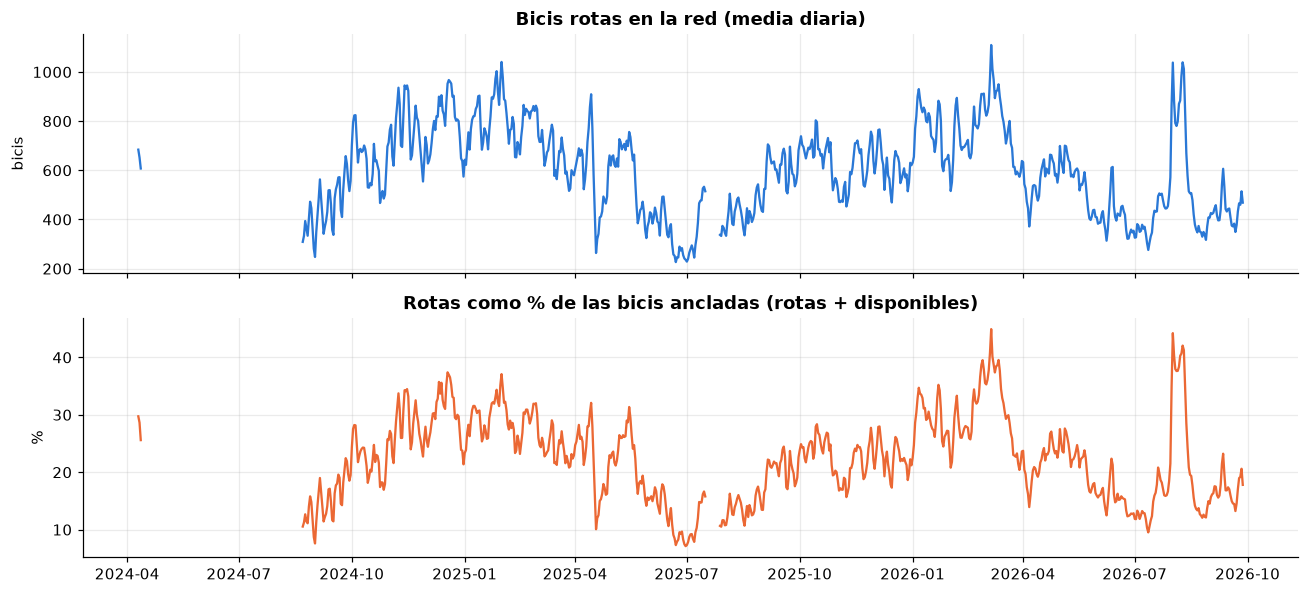

In [36]:
foto = df.groupby("committed_at_utc").agg(rotas=("num_bikes_disabled", "sum"), disp=("num_bikes_available", "sum"))
foto.index = foto.index.tz_convert(TZ)
foto["pct_rotas"] = foto.rotas / (foto.rotas + foto.disp) * 100
diaria = foto.resample("D").mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True)
axes[0].plot(diaria.index, diaria.rotas, color=BLUE, lw=1.5)
axes[0].set(ylabel="bicis", title="Bicis rotas en la red (media diaria)")
axes[1].plot(diaria.index, diaria.pct_rotas, color=ORANGE, lw=1.5)
axes[1].set(ylabel="%", title="Rotas como % de las bicis ancladas (rotas + disponibles)")
plt.tight_layout()

,nombre,capacidad,rotas_media,pct_fotos_5_rotas,pct_fotos_vacia,rotas_%_capacidad
station_id,,,,,,
571,320 - PEDRO LOZANO,0.0,0.0,0.0,100.0,NaN
589,016 - MUSEO DEL AGUA,16.0,1.6,7.7,44.1,10.0
45,045 - Uruguay,20.0,1.4,5.8,43.8,7.2
32,032 - Catedral,18.0,2.3,14.7,43.7,13.0
191,191 - Rivadavia y 9 de Julio,16.0,1.4,5.3,42.3,8.5
36,036 - MAIPÚ,12.0,2.1,11.9,42.2,17.6
174,174 - MINISTERIO DE EDUCACION,20.0,1.8,7.7,41.9,8.8
132,132 - CORRIENTES,12.0,2.0,8.8,41.8,16.9
541,198 - CENTRO METROPOLITANO DE DISEÑO,12.0,1.1,3.2,41.8,9.1


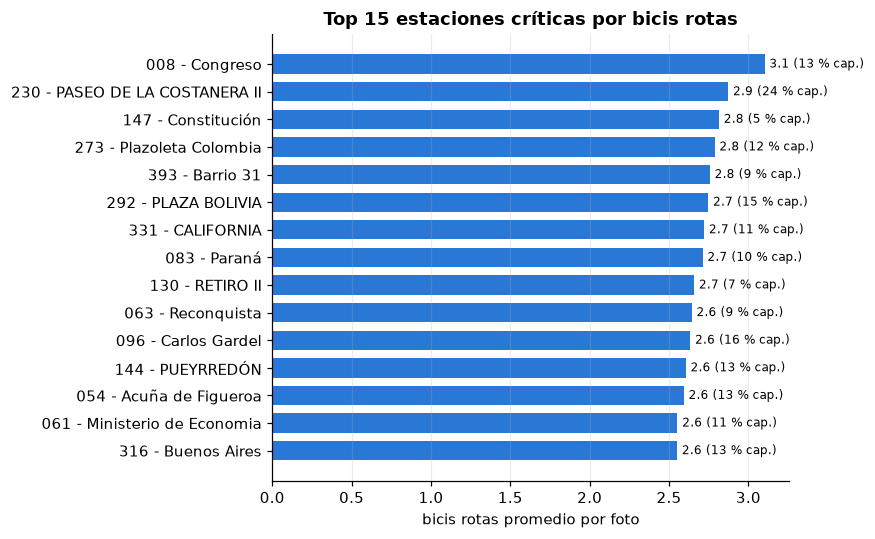

In [37]:
crit = df.groupby("station_id", observed=True).agg(
    nombre=("name", "last"), capacidad=("capacity", "median"),
    rotas_media=("num_bikes_disabled", "mean"),
    pct_fotos_5_rotas=("num_bikes_disabled", lambda s: (s >= 5).mean() * 100),
    pct_fotos_vacia=("num_bikes_available", lambda s: (s == 0).mean() * 100))
crit["rotas_%_capacidad"] = crit.rotas_media / crit.capacidad.replace(0, np.nan) * 100

top = crit.nlargest(15, "rotas_media").sort_values("rotas_media")
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top.nombre, top.rotas_media, color=BLUE, height=0.7)
for y, (v, p) in enumerate(zip(top.rotas_media, top["rotas_%_capacidad"])):
    ax.text(v + 0.03, y, f"{v:.1f} ({p:.0f} % cap.)", va="center", fontsize=8)
ax.set(xlabel="bicis rotas promedio por foto", title="Top 15 estaciones críticas por bicis rotas")
ax.grid(axis="y", visible=False)
plt.tight_layout()
crit.nlargest(10, "pct_fotos_vacia").round(1)

El porcentaje de rotas oscila (promedio mensual) entre ~11 % (invierno 2025) y ~32 % (marzo 2026), más alto en verano,
con picos diarios de ~45 % en marzo y agosto de 2026. **008 – Congreso** es la más crítica en valor absoluto
(3,1 rotas por foto); en términos relativos, **230 – Paseo de la Costanera II** (≈ 24 % de su capacidad). La tabla muestra además
las estaciones que pasan más tiempo vacías (≈ 40–44 % de las fotos en el microcentro).

## 7. Inventario de calidad

Cada problema detectado, con su evidencia cuantificada en código y la acción propuesta para el pipeline.

In [38]:
n = len(df)
inv = pd.DataFrame([
    ("Cobertura", "Hueco abr–ago 2024 sin fotos", f"{huecos.horas.max():,.0f} h", "excluir del entrenamiento"),
    ("Cobertura", "Hueco 16–28 jul 2025", f"{huecos[huecos.desde.dt.year.eq(2025) & huecos.desde.dt.month.eq(7)].horas.sum():,.0f} h", "excluir / no imputar"),
    ("Cobertura", "Huecos > 3 h en total", f"{len(huecos)} huecos", "marcar horas sin dato"),
    ("Resolución", "Intervalo mediano > 30 min en 2026",
     ", ".join(f"{k}: {v:.0f}" for k, v in cob["intervalo mediano (min)"].loc["2026-02":"2026-08"].items()), "corregir proxy o excluir feb–ago 2026"),
    ("Resolución", "Pocas fotos 21–23 h", f"{por_hora.loc[21:23].mean():.0f} vs {por_hora.drop([21, 22, 23]).mean():.0f} fotos/hora", "no interpretar la caída nocturna"),
    ("Cobertura", "Celdas estación-hora sin foto", f"{1 - grilla.notna().mean().mean():.1%}", "imputar sólo huecos cortos"),
    ("Esquema", "external_id aparece desde abr-2026 (UUID)", f"{df.external_id.isna().mean():.0%} nulo en total", "documentar cambio de feed"),
    ("Coordenadas", "Latitud con signo invertido (066 Billinghurst)", f"{len(fuera):,} filas (oct–dic 2024)", "corregir signo"),
    ("Nulos", "short_name nulo o vacío", f"{vacios / n:.0%}", "descartar columna"),
    ("Constantes", "status, is_installed, is_renting, is_returning casi constantes",
     f"{(df.status != 'IN_SERVICE').sum()} filas no IN_SERVICE", "descartar"),
    ("Identidad", "Estaciones renombradas", f"{dup['estaciones con > 1 nombre']}", "usar station_id"),
    ("Identidad", "Nombre compartido por 2 station_id", f"{dup['nombres usados por > 1 station_id']}", "usar station_id"),
    ("Identidad", "Estaciones que cambian coordenadas", f"{dup['estaciones con > 1 coordenada']}", "usar última coordenada"),
    ("Identidad", "Estaciones que cambian capacidad", f"{dup['estaciones con > 1 capacidad']}", "capacidad como serie temporal"),
    ("Consistencia", "bicis + docks ≠ capacidad", f"{(tot != df.capacity).mean():.1%} de filas", "no usar capacity como total"),
    ("Consistencia", "capacity = 0", f"{(df.capacity == 0).sum():,} filas", "excluir estación"),
    ("Outliers", "Saltos ≥ 10 bicis (rebalanceo)", f"{len(rebal):,} ({rebal.delta.gt(0).mean():.0%} subidas)", "excluir del proxy de devoluciones"),
    ("Outliers", "IQR en estación-hora", f"{(sh.retiros > upper).mean():.1%} marcadas", "criterio por estación"),
    ("Clima", "~7 pronósticos por hora", f"{dup['clima: filas con forecast_at_utc repetido']:,} filas repetidas", "deduplicar (pronóstico más cercano)"),
    ("Clima", "Horas sin pronóstico",
     f"{len(pd.date_range(w.forecast_at_utc.min(), w.forecast_at_utc.max(), freq='h')) - w.forecast_at_utc.nunique():,}", "alinear con huecos de fotos"),
    ("Clima", "Es pronóstico, no observación", "lead de −24 a +23 h", "documentar"),
    ("Viajes", "Formato distinto por año (BOM, sufijo BAEcobici, miles con ',')",
     "; ".join(f"{a}: sufijo {f['% IDs con sufijo BAEcobici']:.0f} %, coma {f['% duraciones con coma']:.0f} %"
               for a, f in formato.items()), "normalizar al leer"),
    ("Viajes", "Limpieza distinta por año: < 60 s", "; ".join(f"{a}: {v:.1f} %" for a, v in cortos.pct_menos_60s.items()),
     "descartar < 61 s en todos los años"),
    ("Viajes", "Misma estación y < 2 min", "; ".join(f"{a}: {v:.1f} %" for a, v in vuelta["% misma estación y < 2 min"].items()),
     "descartar"),
    ("Viajes", "Duraciones extremas", f"{(tr.duracion_s > lim_log[1]).mean():.1%} sobre IQR log ({lim_log[1] / 60:.0f} min); máx {tr.duracion_s.max() / 86400:.0f} días",
     "recortar"),
    ("Viajes", "id_recorrido duplicado", f"{tr.id_recorrido.duplicated().sum()}", "deduplicar"),
    ("Viajes", "fecha_destino nula", f"{tr.fecha_destino.isna().sum():,}", "descartar o imputar con duración"),
    ("Target", "Proxy subestima y depende de la resolución", "ver sección 8", "usar sólo períodos con fotos ≤ 30 min"),
], columns=["tipo", "problema", "cuantificación", "acción"])
inv

,tipo,problema,cuantificación,acción
0,Cobertura,Hueco abr–ago 2024 sin fotos,"3,168 h",excluir del entrenamiento
1,Cobertura,Hueco 16–28 jul 2025,279 h,excluir / no imputar
2,Cobertura,Huecos > 3 h en total,118 huecos,marcar horas sin dato
3,Resolución,Intervalo mediano > 30 min en 2026,"2026-02: 24, 2026-03: 24, 2026-04: 30, 2026-05...",corregir proxy o excluir feb–ago 2026
4,Resolución,Pocas fotos 21–23 h,1076 vs 2404 fotos/hora,no interpretar la caída nocturna
5,Cobertura,Celdas estación-hora sin foto,25.0%,imputar sólo huecos cortos
6,Esquema,external_id aparece desde abr-2026 (UUID),89% nulo en total,documentar cambio de feed
7,Coordenadas,Latitud con signo invertido (066 Billinghurst),"5,265 filas (oct–dic 2024)",corregir signo
8,Nulos,short_name nulo o vacío,99%,descartar columna
9,Constantes,"status, is_installed, is_renting, is_returning...",6 filas no IN_SERVICE,descartar


## 8. Confiabilidad del target

Se compara el **proxy de retiros** (fotos ≤ 30 min) con los **viajes reales de BA Data** contados por estación de origen
y hora de inicio. Se usan todos los viajes (un retiro rechazado también saca la bici del dock) y sólo las
estación-hora que tienen al menos una foto, desde abril de 2024 hasta agosto de 2026 (último mes publicado).

### 8.1 Alineación temporal

Antes de comparar hay que confirmar la zona horaria de BA Data: se correlaciona el total de la red por hora con los
viajes desplazados −4 a +4 horas.

In [39]:
vj = tr.groupby(["id_estacion_origen", "hour"], observed=True).size().rename("viajes").reset_index()
vj = vj.rename(columns={"id_estacion_origen": "station_id"}).astype({"station_id": str})
comp = sh.retiros.rename("proxy").reset_index().astype({"station_id": str})
comp = comp.merge(vj, on=["station_id", "hour"], how="left").fillna({"viajes": 0})
comp = comp[(comp.hour >= tr.hour.min()) & (comp.hour <= tr.hour.max())]
comp["fotos_hora"] = comp.hour.map(fotos.dt.floor("h").value_counts())

red_p = comp.groupby("hour").proxy.sum()
red_v = comp.groupby("hour").viajes.sum()
lag = pd.Series({s: red_p.corr(red_v.shift(s, freq="h")) for s in range(-4, 5)}, name="corr red-hora")
lag.index.name = "desplazamiento de los viajes (h)"
lag.round(3).to_frame().T

desplazamiento de los viajes (h),-4,-3,-2,-1,0,1,2,3,4
corr red-hora,0.504,0.603,0.706,0.798,0.819,0.732,0.583,0.411,0.25


La correlación es máxima sin desplazamiento: **BA Data publica en hora local de Buenos Aires**, igual que `ts`.

### 8.2 Tabla de confiabilidad

In [40]:
def confiabilidad(c):
    sd = c.groupby(["station_id", c.hour.dt.date])[["proxy", "viajes"]].sum()
    nh = c.groupby("hour")[["proxy", "viajes"]].sum()
    return pd.Series({
        "corr estación-hora": c.proxy.corr(c.viajes),
        "corr estación-día": sd.proxy.corr(sd.viajes),
        "corr red-hora": nh.proxy.corr(nh.viajes),
        "% retiros capturados": c.proxy.sum() / c.viajes.sum() * 100,
        "estación-hora": len(c),
        "viajes": c.viajes.sum(),
    })


corte = pd.Timestamp("2026-02-01", tz=TZ)
buena = comp[comp.hour < corte]
tabla8 = pd.DataFrame({
    "Todo el solape (abr-2024 → ago-2026)": confiabilidad(comp),
    "Resolución buena (hasta ene-2026)": confiabilidad(buena),
    "Resolución buena y ≥ 3 fotos en la hora": confiabilidad(buena[buena.fotos_hora >= 3]),
    "Resolución degradada (feb → ago-2026)": confiabilidad(comp[comp.hour >= corte]),
}).T
tabla8.loc["Propuesta (referencia)"] = [0.73, 0.93, 0.98, 66, np.nan, np.nan]
tabla8.style.format({"corr estación-hora": "{:.3f}", "corr estación-día": "{:.3f}", "corr red-hora": "{:.3f}",
                     "% retiros capturados": "{:.1f}", "estación-hora": "{:,.0f}", "viajes": "{:,.0f}"}, na_rep="—")

,corr estación-hora,corr estación-día,corr red-hora,% retiros capturados,estación-hora,viajes
Todo el solape (abr-2024 → ago-2026),0.676,0.825,0.819,52.4,"6,523,032","6,386,610"
Resolución buena (hasta ene-2026),0.725,0.922,0.920,61.6,"4,846,275","4,890,075"
Resolución buena y ≥ 3 fotos en la hora,0.749,0.929,0.976,67.1,"4,169,029","4,387,475"
Resolución degradada (feb → ago-2026),0.469,0.608,0.565,22.3,"1,676,757","1,496,535"
Propuesta (referencia),0.730,0.930,0.980,66.0,—,—


### 8.3 Confiabilidad mes a mes vs. resolución de las fotos

,corr estación-hora,corr estación-día,corr red-hora,% retiros capturados,viajes,intervalo mediano (min)
hour,,,,,,
2024-04,0.700,0.928,0.842,51.464,25760.0,15.0
2024-08,0.729,0.933,0.964,61.600,72289.0,15.2
2024-09,0.716,0.918,0.944,57.242,347548.0,15.3
2024-10,0.713,0.915,0.939,56.425,373031.0,15.3
2024-11,0.700,0.914,0.932,56.572,355449.0,15.5
2024-12,0.708,0.918,0.925,58.924,326935.0,15.4
2025-01,0.720,0.924,0.902,65.617,300701.0,15.4
2025-02,0.725,0.929,0.911,66.151,260301.0,15.4
2025-03,0.742,0.933,0.923,63.795,288770.0,15.7


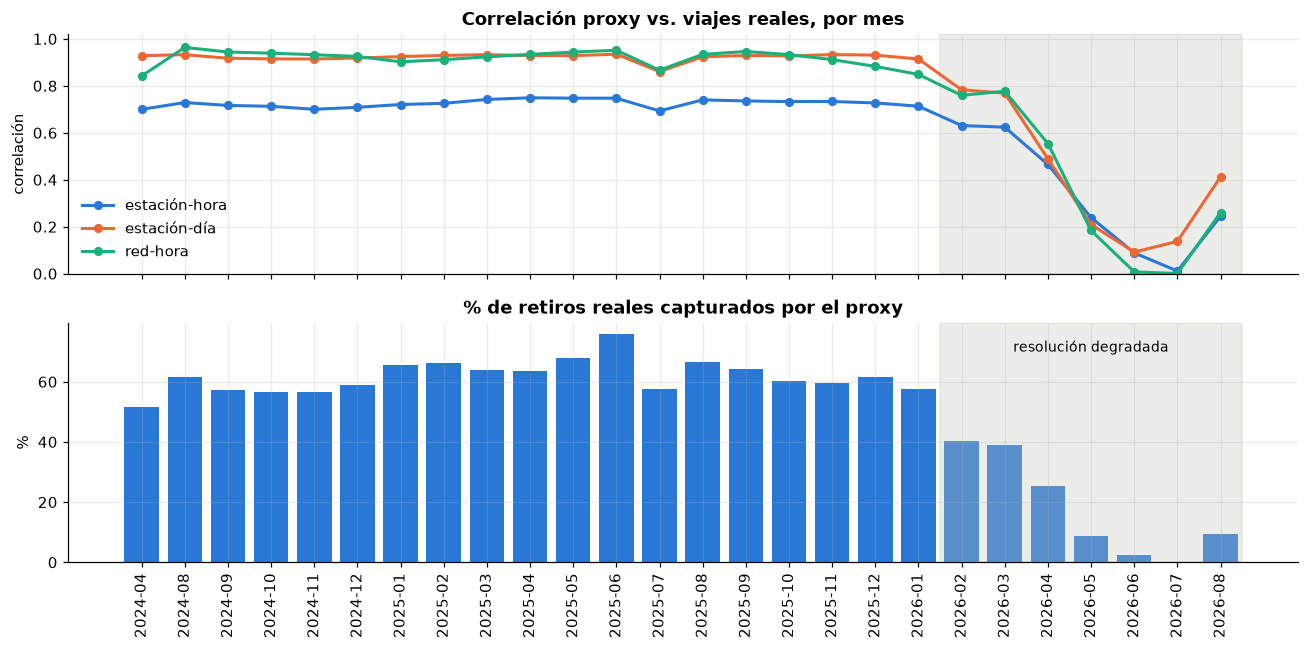

In [41]:
mensual8 = comp.groupby(comp.hour.dt.tz_localize(None).dt.to_period("M")).apply(confiabilidad, include_groups=False)
mensual8["intervalo mediano (min)"] = cob["intervalo mediano (min)"].reindex(mensual8.index)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
x = mensual8.index.astype(str)
for col, c in zip(["corr estación-hora", "corr estación-día", "corr red-hora"], [BLUE, ORANGE, AQUA]):
    axes[0].plot(x, mensual8[col], color=c, lw=2, marker="o", ms=5, label=col.replace("corr ", ""))
axes[0].set(ylabel="correlación", ylim=(0, 1.02), title="Correlación proxy vs. viajes reales, por mes")
axes[0].legend(frameon=False, loc="lower left")
axes[1].bar(x, mensual8["% retiros capturados"], color=BLUE, width=0.8)
axes[1].set(ylabel="%", title="% de retiros reales capturados por el proxy")
for ax in axes:
    ax.axvspan(x.get_loc("2026-02") - 0.5, len(x) - 0.5, color="#c3c2b7", alpha=0.3)
axes[1].text(x.get_loc("2026-05"), 70, "resolución degradada", ha="center", fontsize=9)
plt.xticks(rotation=90)
plt.tight_layout()
mensual8.drop(columns=["estación-hora"]).round(3)

### 8.4 Captura por hora del día (período con resolución buena)

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
proxy,60648.0,63845.0,42890.0,26361.0,19653.0,36372.0,64563.0,130068.0,153440.0,129891.0,125363.0,140810.0,175821.0,194010.0,187513.0,215655.0,246795.0,270777.0,259704.0,210032.0,190019.0,42618.0,418.0,23599.0
viajes,95772.0,70136.0,40247.0,24237.0,21740.0,41480.0,84614.0,174802.0,213252.0,187557.0,171135.0,198500.0,260335.0,287723.0,285332.0,327651.0,404744.0,461920.0,449246.0,341341.0,288167.0,205112.0,145398.0,109634.0
% capturado,63.3,91.0,106.6,108.8,90.4,87.7,76.3,74.4,72.0,69.3,73.3,70.9,67.5,67.4,65.7,65.8,61.0,58.6,57.8,61.5,65.9,20.8,0.3,21.5
fotos por hora (media),3.2,3.8,3.9,3.9,4.0,3.9,3.9,3.9,4.0,3.1,3.8,3.9,3.9,3.9,3.9,3.9,4.0,4.0,3.9,3.9,4.0,1.9,1.1,1.9


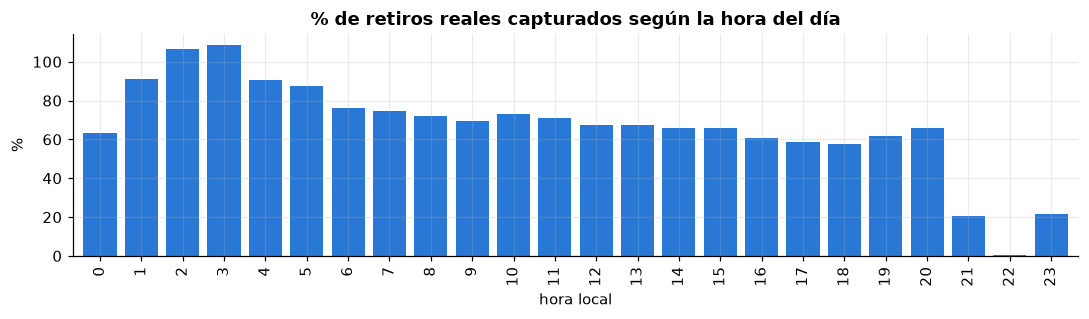

In [42]:
por_hora8 = buena.groupby(buena.hour.dt.hour)[["proxy", "viajes"]].sum()
por_hora8["% capturado"] = por_hora8.proxy / por_hora8.viajes * 100
por_hora8["fotos por hora (media)"] = buena.groupby(buena.hour.dt.hour).fotos_hora.mean()
ax = por_hora8["% capturado"].plot.bar(color=BLUE, figsize=(10, 3), width=0.8)
ax.set(xlabel="hora local", ylabel="%", title="% de retiros reales capturados según la hora del día")
plt.tight_layout()
por_hora8.round(1).T

**Lectura.**
- **Se reproduce la propuesta, pero sólo en horas bien muestreadas.** Con resolución buena y ≥ 3 fotos en la hora:
  0,75 (estación-hora), 0,93 (estación-día), 0,98 (red-hora) y 67 % capturado, contra 0,73 / 0,93 / 0,98 / 66 % de la
  propuesta. Si se incluyen las horas con 1–2 fotos, red-hora baja a 0,92 y la captura a 62 %.
- **Feb–ago 2026 no sirve como target:** 0,47 / 0,61 / 0,57 y 22 % capturado; en junio–julio de 2026 la correlación
  es prácticamente nula. Coincide con el intervalo mediano > 30 min de la sección 3.
- **La captura depende de la hora:** ~65–75 % de día, ~58 % en el pico de 17–18 h (más retiros y devoluciones que se
  cancelan dentro del mismo intervalo), ~0–21 % entre las 21 y las 23 h (pocas fotos) y > 100 % a las 2–3 h
  (bajadas por rebalanceo nocturno contadas como retiros).
- **Implicancias para el modelo:**
  1. Definir el target a nivel **estación-día** o **red-hora**; a nivel estación-hora el proxy explica ~55 % de la varianza
     (r ≈ 0,75).
  2. Entrenar sólo con períodos de fotos ≤ 30 min y horas con ≥ 3 fotos; excluir feb–ago 2026 y la franja de 21 a 23 h.
  3. El proxy **subestima ~35–40 %** la demanda: si importa el nivel absoluto, calibrarlo con los viajes (factor ≈ 1/0,62)
     o usar directamente los viajes de BA Data donde estén publicados.